In [92]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import LabelEncoder
import lightgbm as lgb
from sklearn.model_selection import train_test_split


In [93]:
train_df = pd.read_csv("Datast/train.csv")
test_df = pd.read_csv("Datast/test.csv")
building_df = pd.read_csv("Datast/building_metadata.csv")
weather_train_df = pd.read_csv("Datast/weather_train.csv")
weather_test_df = pd.read_csv("Datast/weather_test.csv")

In [94]:
print("train_df_shape ",train_df.shape,'\n',train_df.isna().sum())
print("building_df_shape",building_df.shape,'\n',building_df.isna().sum())
print("weather_train_df_shape",weather_train_df.shape,'\n',weather_train_df.isna().sum())

train_df_shape  (20216100, 4) 
 building_id      0
meter            0
timestamp        0
meter_reading    0
dtype: int64
building_df_shape (1449, 6) 
 site_id           0
building_id       0
primary_use       0
square_feet       0
year_built      774
floor_count    1094
dtype: int64
weather_train_df_shape (139773, 9) 
 site_id                   0
timestamp                 0
air_temperature          55
cloud_coverage        69173
dew_temperature         113
precip_depth_1_hr     50289
sea_level_pressure    10618
wind_direction         6268
wind_speed              304
dtype: int64


In [159]:
wet_cop=weather_train_df.copy()
buil_cop=building_df.copy()

In [160]:

wet_cop["timestamp"] = pd.to_datetime(wet_cop["timestamp"])
wet_cop["hour"] = wet_cop["timestamp"].dt.hour
wet_cop["day"] = wet_cop["timestamp"].dt.day
wet_cop["month"] = wet_cop["timestamp"].dt.month
wet_cop["year"] = wet_cop["timestamp"].dt.year
wet_cop["weekend"] = (wet_cop["timestamp"].dt.weekday >= 5).astype(int)
wet_cop = wet_cop.set_index("timestamp")


In [117]:
wet_cop.sort_values(["site_id", "timestamp"], inplace=True)

In [118]:
wet_cop["cloud_coverage"] = wet_cop.groupby("site_id")["cloud_coverage"].transform(
    lambda x: x.interpolate(method="time")
    .ffill()
    .bfill()
)

wet_cop["cloud_coverage"] = (wet_cop.groupby(["site_id", "hour", "month"])["cloud_coverage"].transform(lambda x: x.fillna(x.median())))

c:\Users\zyzai\miniconda3\envs\appml\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
c:\Users\zyzai\miniconda3\envs\appml\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
c:\Users\zyzai\miniconda3\envs\appml\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
c:\Users\zyzai\miniconda3\envs\appml\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
c:\Users\zyzai\miniconda3\envs\appml\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
c:\Users\zyzai\miniconda3\envs\appml\Lib\site-packages\numpy\lib\_nanf

In [125]:
missing_percentage = wet_cop.isnull().sum() / len(wet_cop) * 100
print(missing_percentage.sort_values(ascending=False))

cloud_coverage        12.325700
sea_level_pressure     7.596603
wind_direction         4.484414
wind_speed             0.217496
dew_temperature        0.080845
air_temperature        0.039350
site_id                0.000000
precip_depth_1_hr      0.000000
hour                   0.000000
day                    0.000000
month                  0.000000
weekend                0.000000
precip_1h_category     0.000000
is_light_rain          0.000000
is_heavy_rain          0.000000
dtype: float64


In [121]:
bins = [-0.1, 0.1, 5.0, 15.0, float('inf')]  # -0.1 to catch near-zero values  
labels = ['No Rain', 'Light Rain', 'Moderate Rain', 'Heavy Rain']  

wet_cop['precip_1h_category'] = pd.cut(
    wet_cop['precip_depth_1_hr'],  
    bins=bins,  
    labels=labels  
)

In [122]:
print(wet_cop['precip_1h_category'].value_counts(normalize=True) * 100)

precip_1h_category
No Rain          91.663626
Light Rain        4.892934
Moderate Rain     2.027573
Heavy Rain        1.415867
Name: proportion, dtype: float64


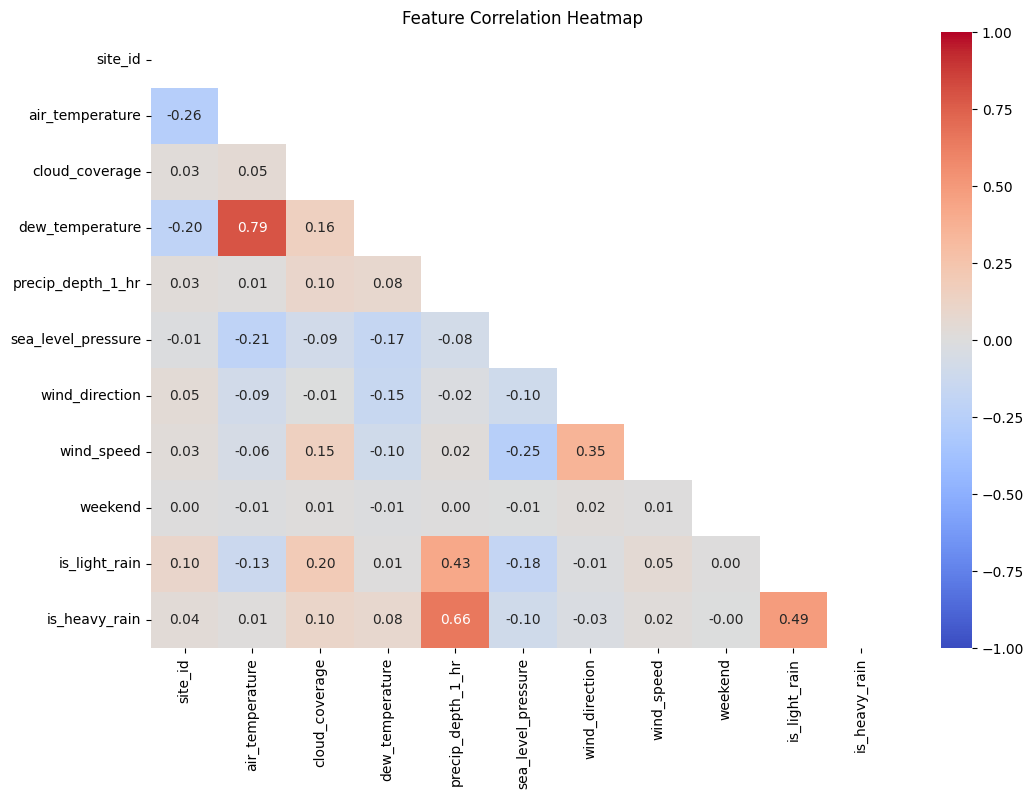

In [127]:
numeric_cols = wet_cop.select_dtypes(include=['float64', 'int64']).columns
corr_df = wet_cop[numeric_cols].corr()

import seaborn as sns
plt.figure(figsize=(12, 8))
sns.heatmap(
    corr_df, 
    annot=True, 
    fmt=".2f", 
    cmap="coolwarm", 
    vmin=-1, 
    vmax=1,
    mask=np.triu(np.ones_like(corr_df)))  # Hide upper triangle
plt.title("Feature Correlation Heatmap")
plt.show()

In [120]:

wet_cop['precip_depth_1_hr'] = (
    wet_cop['precip_depth_1_hr']
    .replace(-1.0, np.nan)
    .interpolate(method='linear', limit=6)  # 6-hour gap limit
    .fillna(0)  # Fill remaining gaps with 0
)

In [123]:
wet_cop['is_light_rain'] = (wet_cop['precip_depth_1_hr'] > 0.1).astype(int)  
wet_cop['is_heavy_rain'] = (wet_cop['precip_depth_1_hr'] > 10.0).astype(int)  

In [140]:
wet_cop['precip_6h_mean'] = (
    wet_cop.groupby('site_id')['precip_depth_1_hr']
    .transform(lambda x: x.rolling(6, min_periods=1).mean())
)

In [150]:
T_min = -10  # Below this, heating load is maxed
T_max = 35   # Above this, cooling load is maxed

wet_cop['feels_like_capped'] = wet_cop['feels_like'].clip(T_min, T_max)

array([[<Axes: title={'center': 'site_id'}>,
        <Axes: title={'center': 'air_temperature'}>,
        <Axes: title={'center': 'cloud_coverage'}>,
        <Axes: title={'center': 'dew_temperature'}>],
       [<Axes: title={'center': 'precip_depth_1_hr'}>,
        <Axes: title={'center': 'sea_level_pressure'}>,
        <Axes: title={'center': 'wind_direction'}>,
        <Axes: title={'center': 'wind_speed'}>],
       [<Axes: title={'center': 'hour'}>,
        <Axes: title={'center': 'day'}>,
        <Axes: title={'center': 'month'}>,
        <Axes: title={'center': 'year'}>],
       [<Axes: title={'center': 'weekend'}>, <Axes: >, <Axes: >,
        <Axes: >]], dtype=object)

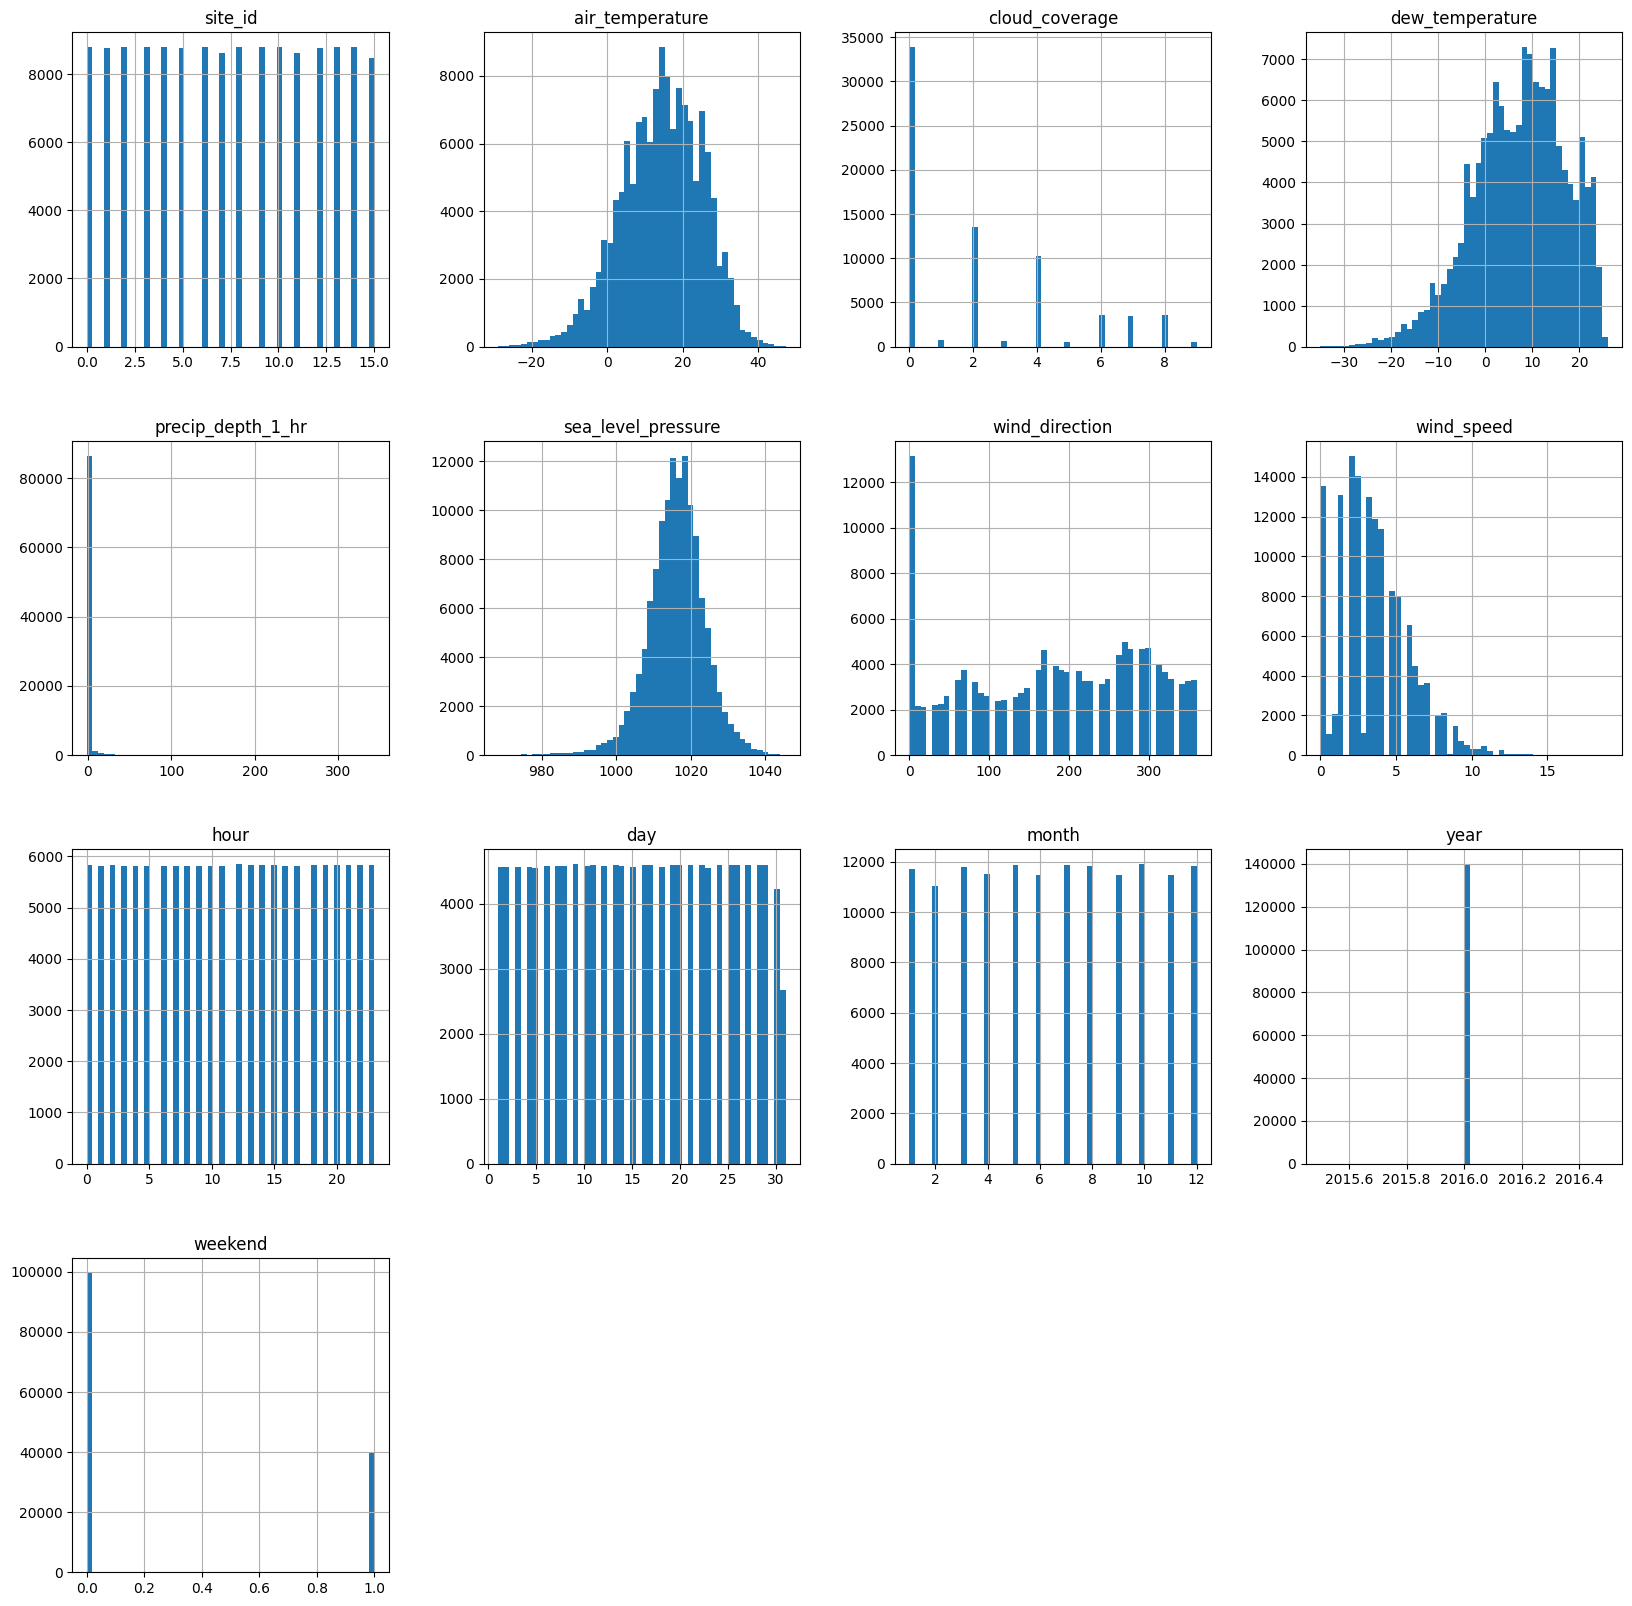

In [161]:
wet_cop.hist(bins=50,figsize=(20,20))

<Axes: ylabel='feels_like_capped'>

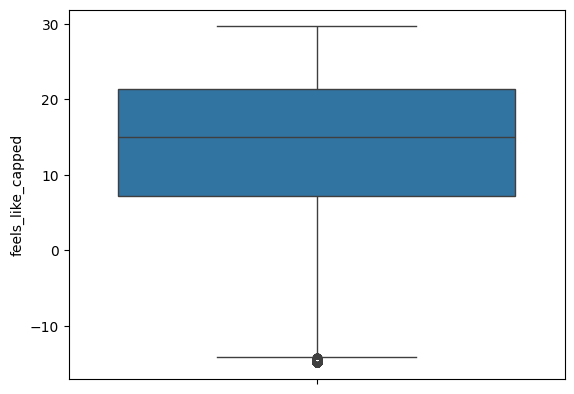

In [144]:
sns.boxplot(wet_cop['feels_like_capped'])

In [129]:
# Simplified heat index (Rothfusz regression approximation)
wet_cop['heat_index'] = (
    0.5 * (wet_cop['air_temperature'] + 61.0 + 
    (wet_cop['air_temperature'] - 68.0) * 1.2 + 
    wet_cop['dew_temperature'] * 0.094
)
)

In [130]:
# Wind chill (for temps < 10°C and wind > 4.8 km/h)
mask = (wet_cop['air_temperature'] < 10) & (wet_cop['wind_speed'] > 1.34)  # 1.34 m/s ≈ 4.8 km/h
wet_cop['wind_chill'] = (
    13.12 + 0.6215 * wet_cop['air_temperature'] - 
    11.37 * (wet_cop['wind_speed'] ** 0.16) + 
    0.3965 * wet_cop['air_temperature'] * (wet_cop['wind_speed'] ** 0.16)
)
wet_cop['wind_chill'] = wet_cop['wind_chill'].where(mask, wet_cop['air_temperature'])

In [131]:
wet_cop['feels_like'] = np.where(
    wet_cop['air_temperature'] >= 27,  # Hot threshold
    wet_cop['heat_index'],
    np.where(
        wet_cop['air_temperature'] <= 10,  # Cold threshold
        wet_cop['wind_chill'],
        wet_cop['air_temperature']  # Default
    )
)

In [133]:
bins = [0, 22.5, 67.5, 112.5, 157.5, 202.5, 247.5, 292.5, 337.5, 360]
labels = ['N', 'NE', 'E', 'SE', 'S', 'SW', 'W', 'NW', 'N']
wet_cop['wind_dir_category'] = pd.cut(
    wet_cop['wind_direction'], bins=bins, labels=labels,ordered=False
)

<Axes: >

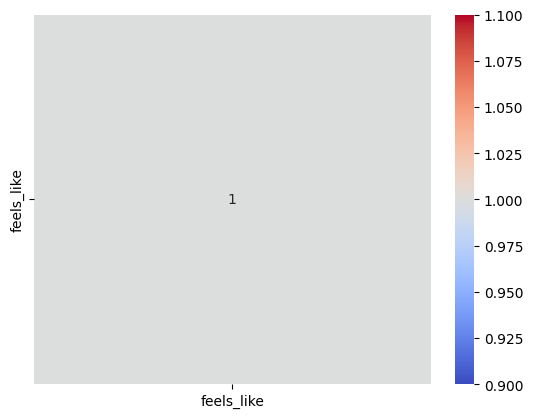

In [128]:
print(wet_cop.columns.tolist())  # Check exact column names

['site_id', 'air_temperature', 'cloud_coverage', 'dew_temperature', 'precip_depth_1_hr', 'sea_level_pressure', 'wind_direction', 'wind_speed', 'hour', 'day', 'month', 'weekend', 'precip_1h_category', 'is_light_rain', 'is_heavy_rain']


In [157]:
train_merged = train_df.merge(buil_cop, on="building_id", how="inner")
train_merged["timestamp"] = pd.to_datetime(train_merged["timestamp"])
train_merged["hour"] = train_merged["timestamp"].dt.hour
train_merged["day"] = train_merged["timestamp"].dt.day
train_merged["month"] = train_merged["timestamp"].dt.month
train_merged["weekend"] = (train_merged["timestamp"].dt.weekday >= 5).astype(int)
train_merged = train_merged.set_index("timestamp")

main_merged = train_merged.merge(wet_cop, on='["site_id", "timestamp"]', how="inner")
main_merged.columns

KeyError: '["site_id", "timestamp"]'

In [ ]:
sns.scatterplot(
    data=main_merged, 
    x='feels_like', 
    y='meter_reading',
    alpha=0.1
)
plt.axvline(T_min, color='blue', linestyle='--', label='Heating Saturation')
plt.axvline(T_max, color='red', linestyle='--', label='Cooling Saturation')
plt.legend()

ValueError: Could not interpret value `meter_reading` for `y`. An entry with this name does not appear in `data`.